# Final Anatomical Variation Score Notebook

This notebook creates a **literature-backed, transparent anatomical variation score** from the QC-filtered TotalSegmentator organ table.

## Main methodological decisions

**1. Patient-level grouping, not scan-level grouping, is required for splitting.**  
Repeated scans from the same case must stay together to avoid leakage. This follows standard medical-AI evaluation guidance and group-aware splitting practice.

**2. The primary score excludes duodenum.**  
Duodenum had missing predictions and one near-empty pseudo-label in the QC stage, so it is kept for a **sensitivity analysis**, not the primary score.

**3. The primary score uses robust standardized deviations.**  
A robust score is less sensitive to a few extreme pseudo-label failures than a simple mean/std z-score.

**4. This notebook creates a _provisional_ score for split construction.**  
After the train/validation/test split is locked, the final score parameters should be re-fit on the training set only and then applied to validation/test.

## Evidence base used for these decisions

- **Patient/group-aware splitting:** scikit-learn `GroupShuffleSplit` / `StratifiedGroupKFold`, and medical-AI leakage guidance for repeated measures.
- **Radiomics/shape-feature standardization:** IBSI / PyRadiomics are the reference standard for shape features.
- **Robust standardization:** robust outlier-style scaling is preferred when a small number of pseudo-label outliers remain after QC.

## Practical note

This notebook uses the features already available in `organ_level_long_qc.csv`:
- `volume_ml_qc`
- `n_slices_present`
- `bbox_size_x`
- `bbox_size_y`
- `bbox_size_z`

These are transparent and reproducible.  
If you later extract PyRadiomics shape features, they can be merged into the same pipeline before locking the final variation score.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start_path=None):
    if start_path is None:
        start_path = Path.cwd()
    start_path = Path(start_path).resolve()
    for path in [start_path] + list(start_path.parents):
        if (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root containing src/")

project_root = find_project_root()

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Current working directory:", Path.cwd())
print("Project root:", project_root)

Current working directory: c:\Users\P102832\Downloads\thesis_segmentation\notebooks\01_eda
Project root: C:\Users\P102832\Downloads\thesis_segmentation


## Load configuration and locate the QC-filtered organ table

Preferred input file:

`metadata/eda/final_mask_level_totalseg/organ_level_long_qc.csv`

If it is not found, the notebook tries a few fallback locations.

In [2]:
config_path = project_root / "configs" / "datasets" / "public_dataset.json"

if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)
else:
    config = {}

candidate_paths = [
    project_root / "metadata" / "eda" / "final_mask_level_totalseg" / "organ_level_long_qc.csv",
    project_root / "metadata" / "eda" / "totalseg_organ_level_eda_qc" / "organ_level_long_table_with_qc.csv",
    project_root / "metadata" / "eda" / "totalseg_organ_level_eda_qc" / "organ_level_long_qc.csv",
    project_root / "organ_level_long_qc.csv",
]

organ_long_qc_path = None
for candidate in candidate_paths:
    if candidate.exists():
        organ_long_qc_path = candidate
        break

if organ_long_qc_path is None:
    raise FileNotFoundError(
        "Could not find organ_level_long_qc.csv. "
        "Save the QC-filtered organ table to metadata/eda/final_mask_level_totalseg/ first."
    )

organ_long_qc_df = pd.read_csv(organ_long_qc_path)

print("Loaded:", organ_long_qc_path)
print("Rows:", len(organ_long_qc_df))
print("Columns:", list(organ_long_qc_df.columns))
organ_long_qc_df.head()

Loaded: C:\Users\P102832\Downloads\thesis_segmentation\metadata\eda\final_mask_level_totalseg\organ_level_long_qc.csv
Rows: 1918
Columns: ['file_name', 'organ_name', 'label_ids', 'present', 'voxel_count', 'volume_mm3', 'volume_ml', 'volume_ml_for_stats', 'fraction_of_scan_voxels', 'shape_x', 'shape_y', 'shape_z', 'spacing_x', 'spacing_y', 'spacing_z', 'first_slice', 'last_slice', 'n_slices_present', 'best_slice', 'bbox_x_min', 'bbox_x_max', 'bbox_y_min', 'bbox_y_max', 'bbox_z_min', 'bbox_z_max', 'bbox_size_x', 'bbox_size_y', 'bbox_size_z', 'qc_flag', 'qc_reason', 'use_for_volume_stats', 'volume_ml_qc']


,file_name,organ_name,label_ids,present,voxel_count,volume_mm3,volume_ml,volume_ml_for_stats,fraction_of_scan_voxels,shape_x,...,bbox_y_max,bbox_z_min,bbox_z_max,bbox_size_x,bbox_size_y,bbox_size_z,qc_flag,qc_reason,use_for_volume_stats,volume_ml_qc
0,case101_day20.nii.gz,spleen,1,True,32740,220995.0,220.995,220.995,0.003213,266,...,183.0,56.0,84.0,64,74,29,ok,NaN,True,220.995
1,case101_day20.nii.gz,kidney_right,2,True,10092,68121.0,68.121,68.121,0.000990,266,...,165.0,34.0,62.0,34,44,29,ok,NaN,True,68.121
2,case101_day20.nii.gz,kidney_left,3,True,16672,112536.0,112.536,112.536,0.001636,266,...,183.0,30.0,63.0,44,38,34,ok,NaN,True,112.536
3,case101_day20.nii.gz,stomach,6,True,85688,578394.0,578.394,578.394,0.008410,266,...,179.0,46.0,80.0,102,96,35,ok,NaN,True,578.394
4,case101_day20.nii.gz,small_bowel,13,True,30068,202959.0,202.959,202.959,0.002951,266,...,163.0,0.0,45.0,130,70,46,ok,NaN,True,202.959


## Define primary and sensitivity organ sets

### Primary score
Use:
- spleen
- kidney_left
- kidney_right
- stomach
- colon
- small_bowel

### Sensitivity score
Use the same organs, **plus duodenum**.

This follows the QC result that duodenum is weaker as a pseudo-label and should not dominate the primary composite score.

In [3]:
PRIMARY_ORGANS = [
    "spleen",
    "kidney_left",
    "kidney_right",
    "stomach",
    "colon",
    "small_bowel",
]

SENSITIVITY_ORGANS = PRIMARY_ORGANS + ["duodenum"]

FEATURES = [
    "volume_ml_qc",
    "n_slices_present",
    "bbox_size_x",
    "bbox_size_y",
    "bbox_size_z",
]

required_columns = ["file_name", "organ_name", "use_for_volume_stats"] + FEATURES

missing_cols = [col for col in required_columns if col not in organ_long_qc_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in organ_long_qc_df: {missing_cols}")

print("Primary organs:", PRIMARY_ORGANS)
print("Sensitivity organs:", SENSITIVITY_ORGANS)
print("Features:", FEATURES)

Primary organs: ['spleen', 'kidney_left', 'kidney_right', 'stomach', 'colon', 'small_bowel']
Sensitivity organs: ['spleen', 'kidney_left', 'kidney_right', 'stomach', 'colon', 'small_bowel', 'duodenum']
Features: ['volume_ml_qc', 'n_slices_present', 'bbox_size_x', 'bbox_size_y', 'bbox_size_z']


## Parse `case_id` and create a scan-level feature table

`case101_day20.nii.gz -> case_id = case101`

This matches the confirmed naming pattern and is the grouping unit we will later use for leakage-safe splitting.

In [4]:
def parse_case_id(file_name: str) -> str:
    stem = str(file_name).replace(".nii.gz", "")
    if "_day" in stem:
        return stem.split("_day")[0]
    return stem.split("_")[0]

organ_long_qc_df["case_id"] = organ_long_qc_df["file_name"].apply(parse_case_id)

scan_feature_rows = []

for organ_name in SENSITIVITY_ORGANS:
    organ_df = organ_long_qc_df[organ_long_qc_df["organ_name"] == organ_name].copy()

    keep_cols = ["file_name", "case_id", "organ_name", "use_for_volume_stats"] + FEATURES
    organ_df = organ_df[keep_cols]

    for feature in FEATURES:
        temp = organ_df[["file_name", "case_id", "organ_name", "use_for_volume_stats", feature]].copy()
        temp["feature_name"] = feature
        temp["feature_value"] = temp[feature]
        temp = temp.drop(columns=[feature])
        scan_feature_rows.append(temp)

variation_features_long_df = pd.concat(scan_feature_rows, ignore_index=True)

# missing or excluded organ-feature values should not enter score fitting
variation_features_long_df.loc[
    ~variation_features_long_df["use_for_volume_stats"], "feature_value"
] = np.nan

variation_features_long_df.head()

,file_name,case_id,organ_name,use_for_volume_stats,feature_name,feature_value
0,case101_day20.nii.gz,case101,spleen,True,volume_ml_qc,220.99500
1,case101_day22.nii.gz,case101,spleen,True,volume_ml_qc,325.45800
2,case101_day26.nii.gz,case101,spleen,True,volume_ml_qc,311.87700
3,case101_day32.nii.gz,case101,spleen,True,volume_ml_qc,522.70650
4,case102_day0.nii.gz,case102,spleen,True,volume_ml_qc,267.36075


## Robust standardization helper

We use a robust score based on the median and MAD (median absolute deviation).

Why:
- pseudo-labels can still contain a few failures after QC
- median/MAD are more stable than mean/std under such outliers

If MAD is zero, the function falls back to IQR scaling, then std scaling, then zero if needed.

In [5]:
def robust_standardize(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").astype(float)
    median = s.median(skipna=True)
    mad = np.nanmedian(np.abs(s - median))

    if np.isnan(median):
        return pd.Series(np.nan, index=s.index)

    if mad and mad > 0:
        return 0.6745 * (s - median) / mad

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if pd.notna(iqr) and iqr > 0:
        return (s - median) / iqr

    std = s.std(skipna=True)
    if pd.notna(std) and std > 0:
        mean = s.mean(skipna=True)
        return (s - mean) / std

    return pd.Series(0.0, index=s.index)

## Compute provisional scan-level variation features

Important:
- this is the **provisional** version used to support split construction
- after the final patient split is locked, the same logic should be re-fit on the **training set only**

In [6]:
variation_features_long_df["robust_z"] = (
    variation_features_long_df
    .groupby(["organ_name", "feature_name"])["feature_value"]
    .transform(robust_standardize)
)

variation_features_long_df["abs_robust_z"] = variation_features_long_df["robust_z"].abs()

variation_features_long_df.head()

,file_name,case_id,organ_name,use_for_volume_stats,feature_name,feature_value,robust_z,abs_robust_z
0,case101_day20.nii.gz,case101,spleen,True,volume_ml_qc,220.99500,-2.041537,2.041537
1,case101_day22.nii.gz,case101,spleen,True,volume_ml_qc,325.45800,-1.480459,1.480459
2,case101_day26.nii.gz,case101,spleen,True,volume_ml_qc,311.87700,-1.553404,1.553404
3,case101_day32.nii.gz,case101,spleen,True,volume_ml_qc,522.70650,-0.421025,0.421025
4,case102_day0.nii.gz,case102,spleen,True,volume_ml_qc,267.36075,-1.792503,1.792503


## Create scan-level primary and sensitivity scores

The score is the **mean absolute robust standardized deviation** across all available organ-feature values for that scan.

In plain words:
> a scan gets a high variation score if many organ features are far from the typical scan.

In [7]:
primary_long_df = variation_features_long_df[
    variation_features_long_df["organ_name"].isin(PRIMARY_ORGANS)
].copy()

sensitivity_long_df = variation_features_long_df[
    variation_features_long_df["organ_name"].isin(SENSITIVITY_ORGANS)
].copy()

scan_primary_score_df = (
    primary_long_df
    .groupby(["file_name", "case_id"])["abs_robust_z"]
    .agg(
        primary_variation_score="mean",
        n_primary_features_used="count",
    )
    .reset_index()
)

scan_sensitivity_score_df = (
    sensitivity_long_df
    .groupby(["file_name", "case_id"])["abs_robust_z"]
    .agg(
        sensitivity_variation_score="mean",
        n_sensitivity_features_used="count",
    )
    .reset_index()
)

scan_variation_scores_df = scan_primary_score_df.merge(
    scan_sensitivity_score_df,
    on=["file_name", "case_id"],
    how="outer",
)

scan_variation_scores_df = scan_variation_scores_df.sort_values(
    ["case_id", "file_name"]
).reset_index(drop=True)

scan_variation_scores_df.head()

,file_name,case_id,primary_variation_score,n_primary_features_used,sensitivity_variation_score,n_sensitivity_features_used
0,case101_day20.nii.gz,case101,1.035121,30,1.106163,35
1,case101_day22.nii.gz,case101,0.843669,30,0.812541,35
2,case101_day26.nii.gz,case101,0.817776,30,0.831204,35
3,case101_day32.nii.gz,case101,0.812438,30,0.977837,35
4,case102_day0.nii.gz,case102,1.214836,30,1.132832,35


## Aggregate from scan level to patient/case level

Because splitting must be done by patient/case, we create one **case-level provisional variation score**.

Aggregation choice:
- median across scans/days per case

Why median:
- robust to one unusual day or one weak pseudo-label
- simpler and more stable than mean in repeated-measure settings

In [8]:
case_variation_scores_df = (
    scan_variation_scores_df
    .groupby("case_id")
    .agg(
        n_scans=("file_name", "count"),
        primary_variation_score=("primary_variation_score", "median"),
        sensitivity_variation_score=("sensitivity_variation_score", "median"),
        n_primary_features_used=("n_primary_features_used", "median"),
        n_sensitivity_features_used=("n_sensitivity_features_used", "median"),
    )
    .reset_index()
    .sort_values("primary_variation_score", ascending=False)
    .reset_index(drop=True)
)

case_variation_scores_df.head()

,case_id,n_scans,primary_variation_score,sensitivity_variation_score,n_primary_features_used,n_sensitivity_features_used
0,case110,2,1.712569,1.573396,30.0,35.0
1,case16,1,1.562197,1.433929,30.0,35.0
2,case15,2,1.377025,1.361345,30.0,35.0
3,case88,3,1.348831,1.409671,30.0,35.0
4,case145,3,1.309141,1.145673,30.0,35.0


## Create provisional variation strata

Primary strata are based on **patient-level primary variation score tertiles**:
- low
- medium
- high

These strata are provisional and are used to support balanced splitting.

In [9]:
def make_tertiles(series: pd.Series) -> pd.Series:
    # qcut with duplicates='drop' avoids failure if tied values occur
    tertiles = pd.qcut(series, q=3, labels=["low", "medium", "high"], duplicates="drop")
    return tertiles

case_variation_scores_df["primary_variation_stratum"] = make_tertiles(
    case_variation_scores_df["primary_variation_score"]
)

case_variation_scores_df["sensitivity_variation_stratum"] = make_tertiles(
    case_variation_scores_df["sensitivity_variation_score"]
)

case_variation_scores_df.head()

,case_id,n_scans,primary_variation_score,sensitivity_variation_score,n_primary_features_used,n_sensitivity_features_used,primary_variation_stratum,sensitivity_variation_stratum
0,case110,2,1.712569,1.573396,30.0,35.0,high,high
1,case16,1,1.562197,1.433929,30.0,35.0,high,high
2,case15,2,1.377025,1.361345,30.0,35.0,high,high
3,case88,3,1.348831,1.409671,30.0,35.0,high,high
4,case145,3,1.309141,1.145673,30.0,35.0,high,high


## Merge scan-level and case-level outputs

These files are the main outputs needed for the next split stage.

In [10]:
scan_variation_scores_df = scan_variation_scores_df.merge(
    case_variation_scores_df[
        [
            "case_id",
            "primary_variation_score",
            "primary_variation_stratum",
            "sensitivity_variation_score",
            "sensitivity_variation_stratum",
        ]
    ],
    on="case_id",
    how="left",
    suffixes=("", "_case"),
)

scan_variation_scores_df.head()

,file_name,case_id,primary_variation_score,n_primary_features_used,sensitivity_variation_score,n_sensitivity_features_used,primary_variation_score_case,primary_variation_stratum,sensitivity_variation_score_case,sensitivity_variation_stratum
0,case101_day20.nii.gz,case101,1.035121,30,1.106163,35,0.830722,medium,0.904521,medium
1,case101_day22.nii.gz,case101,0.843669,30,0.812541,35,0.830722,medium,0.904521,medium
2,case101_day26.nii.gz,case101,0.817776,30,0.831204,35,0.830722,medium,0.904521,medium
3,case101_day32.nii.gz,case101,0.812438,30,0.977837,35,0.830722,medium,0.904521,medium
4,case102_day0.nii.gz,case102,1.214836,30,1.132832,35,1.214836,high,1.132832,high


## Summary tables

In [11]:
variation_strata_summary_df = (
    case_variation_scores_df
    .groupby("primary_variation_stratum")
    .agg(
        n_cases=("case_id", "count"),
        median_score=("primary_variation_score", "median"),
        min_score=("primary_variation_score", "min"),
        max_score=("primary_variation_score", "max"),
        median_scans_per_case=("n_scans", "median"),
    )
    .reset_index()
)

variation_strata_summary_df

,primary_variation_stratum,n_cases,median_score,min_score,max_score,median_scans_per_case
0,low,29,0.603860,0.464115,0.689057,3.0
1,medium,28,0.786597,0.694807,0.917629,3.0
2,high,28,1.098815,0.920694,1.712569,3.0


In [12]:
organ_contribution_df = (
    primary_long_df
    .groupby("organ_name")["abs_robust_z"]
    .mean()
    .reset_index(name="mean_abs_robust_z")
    .sort_values("mean_abs_robust_z", ascending=False)
)

organ_contribution_df

,organ_name,mean_abs_robust_z
1,kidney_left,0.886318
4,spleen,0.880856
2,kidney_right,0.878970
5,stomach,0.855304
0,colon,0.814569
3,small_bowel,0.810907


## Final figures

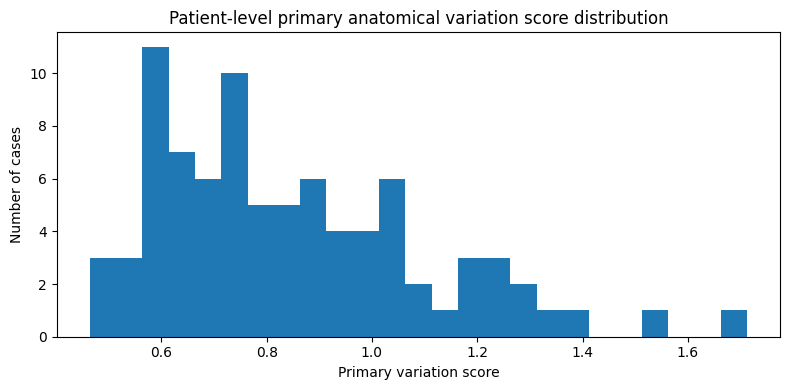

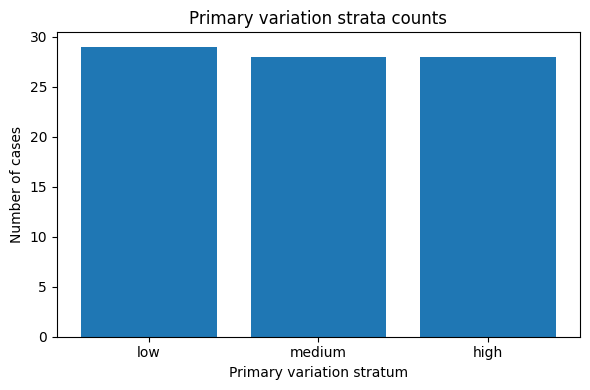

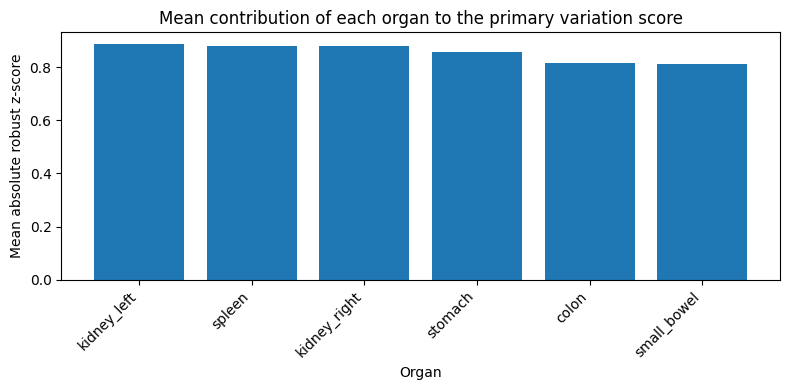

In [13]:
figure_dir = project_root / "docs" / "figures" / "final_variation_score"
figure_dir.mkdir(parents=True, exist_ok=True)

# 1. Patient-level primary variation score distribution
plt.figure(figsize=(8, 4))
plt.hist(case_variation_scores_df["primary_variation_score"], bins=25)
plt.xlabel("Primary variation score")
plt.ylabel("Number of cases")
plt.title("Patient-level primary anatomical variation score distribution")
plt.tight_layout()
plt.savefig(figure_dir / "variation_score_distribution.png", dpi=150)
plt.show()

# 2. Variation stratum counts
stratum_counts = case_variation_scores_df["primary_variation_stratum"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(stratum_counts.index.astype(str), stratum_counts.values)
plt.xlabel("Primary variation stratum")
plt.ylabel("Number of cases")
plt.title("Primary variation strata counts")
plt.tight_layout()
plt.savefig(figure_dir / "variation_strata_counts.png", dpi=150)
plt.show()

# 3. Mean organ contribution
plt.figure(figsize=(8, 4))
plt.bar(organ_contribution_df["organ_name"], organ_contribution_df["mean_abs_robust_z"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Organ")
plt.ylabel("Mean absolute robust z-score")
plt.title("Mean contribution of each organ to the primary variation score")
plt.tight_layout()
plt.savefig(figure_dir / "organ_contribution_barplot.png", dpi=150)
plt.show()

## Optional sensitivity check: how much does duodenum change ranking?

A simple practical question:
> Does adding duodenum change which cases are considered highly variable?

This is not the main score. It is a sensitivity analysis only.

In [14]:
rank_compare_df = case_variation_scores_df[[
    "case_id",
    "primary_variation_score",
    "sensitivity_variation_score",
]].copy()

rank_compare_df["primary_rank"] = rank_compare_df["primary_variation_score"].rank(ascending=False, method="average")
rank_compare_df["sensitivity_rank"] = rank_compare_df["sensitivity_variation_score"].rank(ascending=False, method="average")
rank_compare_df["rank_shift_abs"] = (rank_compare_df["primary_rank"] - rank_compare_df["sensitivity_rank"]).abs()

rank_compare_df = rank_compare_df.sort_values("rank_shift_abs", ascending=False).reset_index(drop=True)
rank_compare_df.head(15)

,case_id,primary_variation_score,sensitivity_variation_score,primary_rank,sensitivity_rank,rank_shift_abs
0,case7,0.555468,0.738785,81.0,52.0,29.0
1,case80,0.660361,0.797156,62.0,41.0,21.0
2,case66,0.862029,1.071135,36.0,17.0,19.0
3,case53,0.714032,0.846845,55.0,36.0,19.0
4,case65,0.917629,1.122348,29.0,13.0,16.0
5,case9,1.019877,1.198937,21.0,6.0,15.0
6,case89,0.756883,0.695702,46.0,60.0,14.0
7,case134,0.970407,1.125106,25.0,12.0,13.0
8,case91,0.627356,0.704894,68.0,56.0,12.0
9,case118,0.681958,0.756850,59.0,49.0,10.0


## Save outputs

These outputs feed directly into the next phase:
- patient-level split construction
- modeling manifest creation
- later training-only re-fitting of the final variation score

In [15]:
output_dir = project_root / "metadata" / "eda" / "final_variation_score"
output_dir.mkdir(parents=True, exist_ok=True)

variation_features_long_df.to_csv(output_dir / "variation_features_long.csv", index=False)
scan_variation_scores_df.to_csv(output_dir / "variation_scores_per_scan.csv", index=False)
case_variation_scores_df.to_csv(output_dir / "variation_scores_per_case.csv", index=False)
variation_strata_summary_df.to_csv(output_dir / "variation_strata_summary.csv", index=False)
organ_contribution_df.to_csv(output_dir / "organ_contribution_summary.csv", index=False)
rank_compare_df.to_csv(output_dir / "variation_score_sensitivity_rank_compare.csv", index=False)

# Split-ready patient table
patient_split_ready_df = case_variation_scores_df[[
    "case_id",
    "n_scans",
    "primary_variation_score",
    "primary_variation_stratum",
    "sensitivity_variation_score",
    "sensitivity_variation_stratum",
]].copy()

patient_split_ready_df.to_csv(output_dir / "patient_split_ready_table.csv", index=False)

print("Saved outputs to:", output_dir)

Saved outputs to: C:\Users\P102832\Downloads\thesis_segmentation\metadata\eda\final_variation_score


## Final interpretation template

Use this wording as a starting point in your thesis/notebook:

> A provisional patient-level anatomical variation score was constructed from QC-filtered organ features derived from TotalSegmentator-predicted masks. The primary score used spleen, kidneys, stomach, colon, and small bowel; duodenum was excluded from the primary score and retained for sensitivity analysis because it showed limited missingness and one near-empty pseudo-label during QC. For each scan, robust standardized deviations were computed for organ volume and spatial-extent features, and the patient-level score was defined as the median scan-level score across repeated scans of the same case. The resulting low/medium/high strata are used to support leakage-safe, patient-level split construction in the next phase. After the final split is locked, the score parameters should be re-fit on the training set only and then applied unchanged to validation and test cases.